In [2]:
import io
import contextlib
import numpy as np

import fmdtools.sim.propagate as prop
from fmdtools.sim.sample import ParameterDomain, ParameterSample
from fmdtools.analyze.tabulate import NominalEnvelope, Comparison
from fmdtools.define.container.parameter import Parameter

from model_main import Beach
from model_environment import BeachEnvironment, BeachBehavior
from model_responder import Responder
from drone import BeachAircraft


def quiet(fn, *a, **k):
    # the model print()s each step; keep the notebook readable
    with contextlib.redirect_stdout(io.StringIO()):
        return fn(*a, **k)

In [3]:
class HazardParam(Parameter):
    victim_x: float = 1000.0        # position along the beach (m)
    victim_y: float = 300.0         # distance offshore (m); water is y >= 200
    distress_onset: float = 100.0   # time (s) the swimmer goes into distress


class HazardBeach(Beach):
    container_p = HazardParam

    def init_architecture(self, **kwargs):
        vic = (self.p.victim_x, self.p.victim_y)
        self.add_flow("environment", BeachEnvironment,
                      c={'p': {'rescue_locations': (vic,)}})
        # distress onset = initial countdown at the victim's tile
        self.flows['environment'].c.set(vic[0], vic[1], "distress_timer",
                                        self.p.distress_onset)
        self.add_fxn("responder", Responder, "environment")
        self.add_fxn("swimmers", BeachBehavior, "environment")
        self.add_fxn("beach_aircraft", BeachAircraft, "environment")

    def classify(self, scen={}, **kwargs):
        # metrics for each parameter-sample run (feeds `res`)
        t_resc = float(self.fxns['responder'].s.time_rescued)
        t_drone = float(self.fxns['beach_aircraft'].s.time_arrived)
        rescued = t_resc >= 0
        return {'prob': getattr(scen, 'prob', 1.0),
                'rescued': rescued,
                'rescue_time': t_resc if rescued else np.nan,
                'rescue_delay': (t_resc - self.p.distress_onset) if rescued else np.nan,
                'drone_helped': t_drone >= 0,
                'classification': 'rescued' if rescued else 'not_rescued'}


# the whole sample runs against a single model instance
mdl = HazardBeach(sp={'end_time': 800})
mdl.sp

SimParam(phases=(('na', 0.0, 800),), start_time=0.0, end_time=800.0, track_times=('all',), dt=1.0, units='hr', end_condition='', use_local=True, with_loadings=False, run_stochastic=False, track_pdf=False)

In [4]:
pdA = ParameterDomain(HazardParam)
pdA.add_variables("victim_x", "victim_y",
                  lims={"victim_x": (200.0, 1800.0), "victim_y": (200.0, 400.0)})
pdA.add_constant("distress_onset", 100.0)
pdA

ParameterDomain with:
 - variables: {'victim_x': (200.0, 1800.0), 'victim_y': (200.0, 400.0)}
 - constants: {'distress_onset': 100.0}
 - parameter_initializer: HazardParam

In [5]:
psA = ParameterSample(pdA)
psA.add_variable_ranges(comb_kwargs={'resolutions': {'victim_x': 400.0,
                                                     'victim_y': 100.0}})
print(len(psA.scenarios()), "scenarios")
psA

15 scenarios


ParameterSample of scenarios:
 - rep0_range_0
 - rep0_range_1
 - rep0_range_2
 - rep0_range_3
 - rep0_range_4
 - rep0_range_5
 - rep0_range_6
 - rep0_range_7
 - rep0_range_8
 - rep0_range_9
 - ... (15 total)

In [6]:
resA, histA = quiet(prop.parameter_sample, mdl, psA, showprogress=False)
resA

rep0_range_0.tend.classify.prob: 0.06666666666666667
rep0_range_0.tend.classify.rescued: True
rep0_range_0.tend.classify.rescue_time: 173.0
rep0_range_0.tend.cl                73.0
rep0_range_0.tend.cl                True
rep0_range_0.tend.cl             rescued
rep0_range_1.tend.classify.prob: 0.06666666666666667
rep0_range_1.tend.classify.rescued: True
rep0_range_1.tend.classify.rescue_time: 193.0
rep0_range_1.tend.cl                93.0
rep0_range_1.tend.cl                True
rep0_range_1.tend.cl             rescued
rep0_range_2.tend.classify.prob: 0.06666666666666667
rep0_range_2.tend.classify.rescued: True
rep0_range_2.tend.classify.rescue_time: 214.0
rep0_range_2.tend.cl               114.0
rep0_range_2.tend.cl                True
rep0_range_2.tend.cl             rescued
rep0_range_3.tend.classify.prob: 0.06666666666666667
rep0_range_3.tend.classify.rescued: True
rep0_range_3.tend.classify.rescue_time: 182.0
rep0_range_3.tend.cl                82.0
rep0_range_3.tend.cl          

(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='p.victim_x', ylabel='p.victim_y'>)

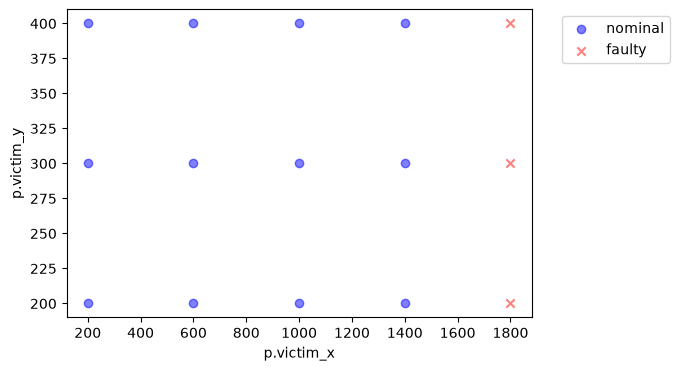

In [7]:
neA = NominalEnvelope(psA, resA, 'rescued', 'p.victim_x', 'p.victim_y',
                      func=lambda x: x == True)
neA.as_plot()

In [8]:
compA = Comparison(resA, psA, metrics=['rescue_delay'],
                   factors=['p.victim_x', 'p.victim_y'])
compA.sort_by_factor('p.victim_y')
compA.sort_by_factor('p.victim_x')
compA.as_table()

rescue_delay
1400.0 400.0         551.0
       300.0         534.0
       200.0         522.0
1000.0 400.0         366.0
       300.0         344.0
       200.0         330.0
600.0  400.0         201.0
       300.0         171.0
200.0  400.0         114.0
       300.0          93.0
600.0  200.0          82.0
200.0  200.0          73.0
1800.0 200.0           NaN
       300.0           NaN
       400.0           NaN

(<Figure size 1200x300 with 1 Axes>, <Axes: xlabel='p.victim_x'>)

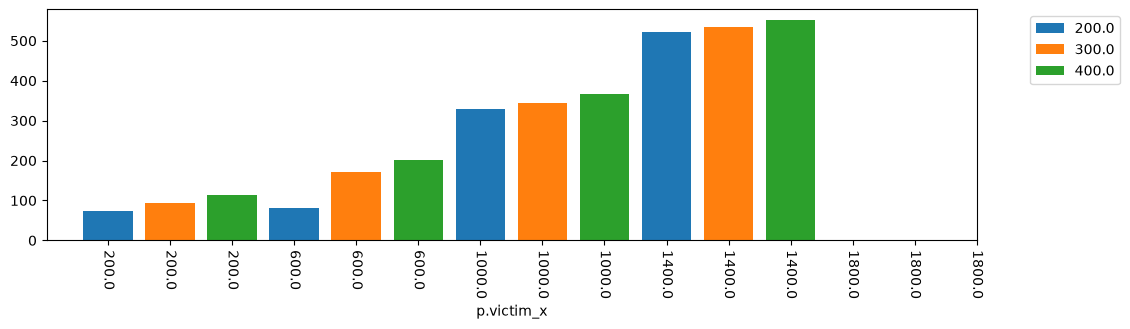

In [9]:
compA.as_plot('rescue_delay', color_factor='p.victim_y', figsize=(12, 3))

In [10]:
resA.state_probabilities()

{'rescued': 0.7999999999999999, 'not_rescued': 0.2}

**Experiment A takeaway:** every far-offshore hazard (`victim_y = 400`) is a coverage gap —
the drone patrols too close to shore to spot them and the responder's cone doesn't reach. In
the water bands the drone/responder do reach, but the wait grows sharply the farther down the
beach the swimmer is from the base at x ≈ 400.

In [11]:
pdB = ParameterDomain(HazardParam)
pdB.add_variables("victim_x", "distress_onset",
                  lims={"victim_x": (400.0, 1600.0), "distress_onset": (50.0, 450.0)})
pdB.add_constant("victim_y", 300.0)

psB = ParameterSample(pdB)
psB.add_variable_ranges(comb_kwargs={'resolutions': {'victim_x': 400.0,
                                                     'distress_onset': 100.0}})
print(len(psB.scenarios()), "scenarios")
resB, histB = quiet(prop.parameter_sample, mdl, psB, showprogress=False)
resB.state_probabilities()

20 scenarios


{'rescued': 0.8500000000000002, 'not_rescued': 0.15000000000000002}

(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='p.victim_x', ylabel='p.distress_onset'>)

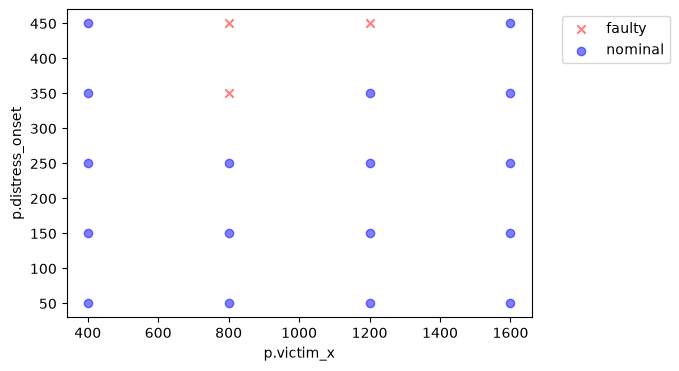

In [12]:
neB = NominalEnvelope(psB, resB, 'rescued', 'p.victim_x', 'p.distress_onset',
                      func=lambda x: x == True)
neB.as_plot()

In [13]:
compB = Comparison(resB, psB, metrics=['rescue_delay'],
                   factors=['p.victim_x', 'p.distress_onset'])
compB.sort_by_factor('p.distress_onset')
compB.sort_by_factor('p.victim_x')
compB.as_table()

rescue_delay
1600.0 50.0          680.0
       150.0         580.0
1200.0 50.0          488.0
1600.0 250.0         480.0
1200.0 150.0         388.0
1600.0 350.0         380.0
       450.0         312.0
800.0  50.0          304.0
1200.0 250.0         288.0
       350.0         216.0
800.0  150.0         204.0
       250.0         128.0
400.0  450.0         102.0
       350.0         100.0
       250.0          98.0
       50.0           94.0
       150.0          78.0
800.0  350.0           NaN
       450.0           NaN
1200.0 450.0           NaN

(<Figure size 1400x300 with 1 Axes>, <Axes: xlabel='p.victim_x'>)

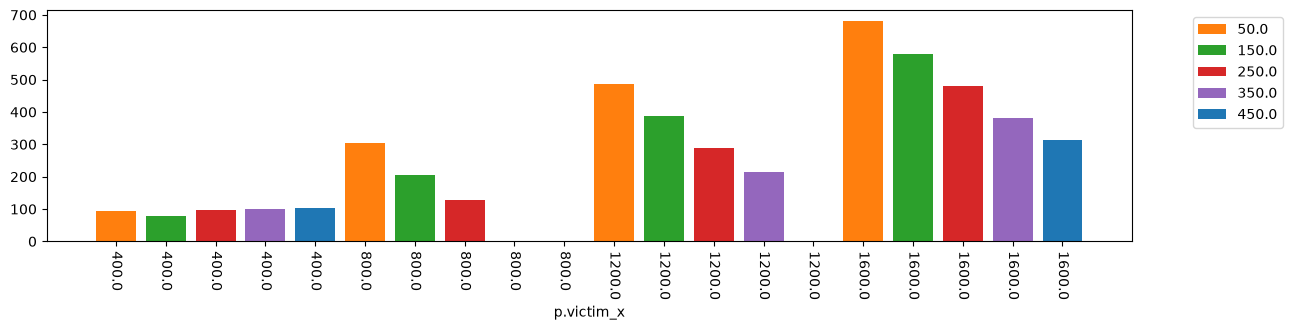

In [14]:
compB.as_plot('rescue_delay', color_factor='p.distress_onset', figsize=(14, 3))

**Experiment B takeaway:** near the base (`victim_x = 400`) the swimmer is always rescued.
At mid-beach positions there are onset times where the drone's patrol has just passed and the
swimmer is never reached — the *same spot* is safe at one distress time and unsafe at another.
That patrol-phase dependence is precisely what sweeping *time* exposes and a single nominal run
would miss.